In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))


<font size="6" color="red">ch10. N차원 배열 다루기</font>
- N차원 배열 객체: 동일 자료형의 집합
- 2차원 배열은 행렬개념으로 이해
- [numpy](https://numpy.org)
  [numpy API Docs](https://numpy.org/doc/stable/reference/index.html)
# 1절. 넘파이 패키지 

In [7]:
import numpy as np
np.__version__ #tensorflow==2.10과 맞는 numpy 버젼 

'1.23.5'

In [10]:
# np.arange(from, stop, by): from부터 stop 앞까지 by 씩 증가하는 1차원 정수 배열 
a=np.arange(15) 
print(a.shape)# 15열 짜리 1차원 배열 
a

(15,)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

## 1.1 배열 속성 

In [21]:
from numpy import arange
a= arange(15, 
          #dtype=np.int8 이렇게안하면 기본 int32 
         ).reshape(3,5)# 3행 5열짜리로 변환 
a 

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [12]:
type(a) 

numpy.ndarray

In [15]:
a.dtype # a 배열의 요소들의 type

dtype('int8')

In [22]:
a.shape #(1차원 15열)

(3, 5)

In [24]:
a.dtype.name

'int32'

In [26]:
a.itemsize #한 요소(item)의 bytesize

4

In [27]:
a.ndim #축수(차원수)

2

In [28]:
a.size # 배열 요소의 갯수 

15

In [29]:
print ('shape 조정전 a:\n', a)
a.shape =(5,3)
print('shape 조정후 a:\n', a)

shape 조정전 a:
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]
shape 조정후 a:
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]]


In [30]:
a.reshape(3,5)

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

## 1.2 배열 타입 변경 


In [31]:
# 배열 요소의 타입변경 (X)

a = np.arange(12).reshape(3,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [32]:
a.size # 요소갯수 

12

In [33]:
a.dtype 

dtype('int32')

In [34]:
a.itemsize

4

In [35]:
a.dtype =np.int64
a.dtype


dtype('int64')

In [36]:
a.itemsize  #요소의 byte 수 

8

In [37]:
a


array([[ 4294967296, 12884901890],
       [21474836484, 30064771078],
       [38654705672, 47244640266]], dtype=int64)

In [38]:
a.size


6

In [40]:
# 배열 요소의 타입변경 (o)
a=arange(15).reshape(5,3)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [44]:
# a.astype(np.int64)  # 출력 o-> a가 바뀌지 않음. 출력x-> a가 바뀜 
a=a.astype(np.int64)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [46]:
a.dtype

dtype('int64')

In [47]:
a.itemsize

8

In [48]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [49]:
a.ravel()# flatten된 배열을 return 

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int64)

In [51]:
a.flatten() #flatten된 배열을 return

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int64)

## 1.3 배열 저장
- pkl(객체, 배열, 머신러닝 모델 저장) vs npy (넘파이 전용포맷, io개선)

In [52]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [61]:
%%time 
import time
start= time.time()
import pickle
with open ('data/ch010.pkl', 'wb') as f:
    pickle.dump(a,f)
end= time.time()
print('실행시간:', (end-start))

실행시간: 0.0015463829040527344
CPU times: total: 0 ns
Wall time: 1.86 ms


In [62]:
%%time
with open ('data/ch010.pkl', 'rb')as f:
    loaded_a = pickle.load(f)
    

CPU times: total: 0 ns
Wall time: 3.75 ms


In [64]:
# a ==(파일저장) ==> 피클파일(269B) ==(load)==> loaded_a 

loaded_a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [65]:
%%time 
np.save('data/ch11.npy', a) #넘파이전용포맷, 빠르고 효율적 안전 

CPU times: total: 0 ns
Wall time: 1.97 ms


In [66]:
%%time 
loaded_a2 = np.load('data/ch11.npy')

CPU times: total: 0 ns
Wall time: 19.8 ms


In [67]:
# a == (저장)==> npy(248B)==(load)==>loaded_a2 
loaded_a2

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

# 2절. 넘파이 배열
- array() 함수를 이용한 다른 파이썬 데이터 구조 (list, tup)를 배열변환 
- 특정값을 갖는 배열 생성함수 : arange, ones, zeros, full, empty....
- 랜덤값을 갖는 배열 생성 함수 ....
- [넘파이함수들](https://numpy.org/doc/stable/reference/index.html)
## 2.1 array ()함수로 넘파이 배열 만들기 
- array(obj, dtype=np.type, copy =T/F)
- array(obj, dtye='type', copy=T/F)
type 예 : int16, int32, float16, float32, float64...


In [69]:
a = np.array([2,14,6]) 
#dtype = np.int16 
 #정수의 기본 타입은 int32 실수의 기본 타입은 floast64 
a, a.dtype

(array([ 2, 14,  6]), dtype('int32'))

In [70]:
a[0], a[1], a[2]

(2, 14, 6)

In [71]:
for item in a:
    print(item, end='\t')

2	14	6	

In [112]:
b = np.array([[1.5, 2.3],[4,5]]) #배열은 동일 자료형의 집합으로 배열 생성: 정수>실수>문자 
b                                # 실수배열의 기본타입 :float64

array([[1.5, 2.3],
       [4. , 5. ]])

In [75]:
b.dtype

dtype('float64')

In [82]:
l=[[1.5,2.3],[4,5]]
l[0][1]

2.3

In [104]:
b=[0,1] #2차원 [axis0=행, axis1=열] cf. 1차원 [axis0=열]

In [83]:
a = np.array([[1.5,2.3], [4,5]], dtype='float32').reshape(1,4)  #dtype= np.float32 
a

array([[1.5, 2.3, 4. , 5. ]], dtype=float32)

In [80]:
a.dtype

dtype('float32')

In [85]:
# a의 배열구조 변경 

a.shape = (2,2)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float32)

In [86]:
# a의 dtype (요소타입)변경 
#a.dttpe =np/float16
a = a.astype(np.float16)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float16)

In [90]:
l =[[1.5, 2.3],
       [4. , 5. ]]
for i in l:
    print(i)
    
for row in l:
    for item in row:
        print(item, end=' ')
    print()

[1.5, 2.3]
[4.0, 5.0]
1.5 2.3 
4.0 5.0 


In [109]:
for i, row in enumerate(l):
    for j, item in enumerate(row):
       # print(f"{i}행{j}열:{b[i][j]}", end='\t') #float16은 소수점 이하가 불안정 
         print(f"{i}행{j}열:{a[i,j]}", end='\t')
    print()

0행0열:1.5	0행1열:2.30078125	
1행0열:4.0	1행1열:5.0	


In [114]:
for row in b:
    for item in row:
        print(item, end=' ')
    print()

1.5 2.3 
4.0 5.0 


In [115]:
#인덱싱 
print(b[0,0]) #인덱싱
#print(b[0,2]) 없는 인덱싱은 에러 

1.5


In [116]:
#슬라이싱 from: stop:by from 부터 stop 전까지 by 씩 전진 , 인덱싱은 음수 
b[0:,1: 10] # 0행부터 끝행 1열부터 끝열까지슬라이싱  (행과 열 모두 슬라이싱=>2차원)

array([[2.3],
       [5. ]])

In [124]:
b[0,1:3] #0행 1열 붜 3열 전까지 슬라이싱 (열만슬라이싱 1차원 배열)

array([2, 3])

In [123]:
b = np.array([[1,2,3], 
              [6,7,8]])
# 모든 행의 마지막 열만 추출 
b[:,-1:], b[:, -1]

(array([[3],
        [8]]),
 array([3, 8]))

In [125]:
# 모든 행의 마지막 열을 제외한 부분 추출 
b[:, :-1]

array([[1, 2],
       [6, 7]])

In [127]:
# 스칼라 변수 
a = 10  #원본 
b = a   #복제본
print("a={}, b={}, a주소={}, b주소={}".format(a,b,id(a), id(b)))
b=-1
print("a={}, b={}, a주소={}, b주소={}".format(a,b,id(a), id(b)))

a=10, b=10, a주소=1580959400464, b주소=1580959400464
a=10, b=-1, a주소=1580959400464, b주소=1580959400112


In [140]:
#numpy 배열 copy=False 해도 깊은 복사가 되는 경우 : dtype이 바뀌면 자동 깊은 복사 
c=np.array ([[1,2],[3,4]], dtype=np.uint16) #원본 
d =c #할당 
d=np.array(c, copy=False, dtype=np.int32)#d=c.copy()와 동일 #깊은 복사
#d=c.copy() #할당 
#d=np.array(c, copy=False)#d=c 동일 #할당 
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print("두변수의 주소:", id(c),id(d))
d[0,0]=9
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print("두변수의 주소:", id(c),id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두변수의 주소: 1581087675312 1581087675600
c=
[[1 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두변수의 주소: 1581087675312 1581087675600


## 2.2 기본값이 있는 배열 만들기
- np.zeros(tup[,dtype]):요소들이 다 0.0 
- np.ones(tup[dtype]): 요소들이 다 1.0
- np.full(tup, 기본값) : 요소들이 다 두번째 매개변수인 기본값
- np.empty(tup) :초기 내용은 임의의 값인 배열(메모리 상태에 따라 달라짐)


※ 위의 함수를 이용해서 생성된 배열은 기본 dtype이 float64, dtype속성을 따로 지정할 수 있음

In [209]:
np.zeros((3,5)) # 3행 5열짜리 2차원 float64 배열 (요소들은 다 0)
np.zeros((5),) # 5열 짜리 1차원 float 64 배열 (요소들은 다 0)
np.zeros(5)# 5열 짜리 1차원 float 64 배열 (요소들은 다 0)

array([0., 0., 0., 0., 0.])

In [215]:
x=np.zeros((2,5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[False False False False False]
 [False False False False False]]
bool
1


In [216]:
np.ones((3,5)) # 3행 5열짜리 2차원 float64 배열 (요소들은 다 1)
np.ones((5),) # 5열 짜리 1차원 float 64 배열 (요소들은 다 1)
np.ones(5)# 5열 짜리 1차원 float 64 배열 (요소들은 다 1)

array([1., 1., 1., 1., 1.])

In [217]:
x=np.ones((2,5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[ True  True  True  True  True]
 [ True  True  True  True  True]]
bool
1


In [219]:
x=np.full((2,5),255)
print(x)
print(x.dtype)

[[255 255 255 255 255]
 [255 255 255 255 255]]
int32


<function matplotlib.pyplot.show(close=None, block=None)>

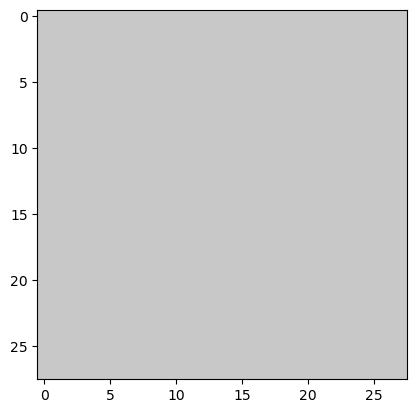

In [238]:
import matplotlib.pyplot as plt
img = np.full((28,28),255, dtype=np.uint8) #흰색
img = np.full((28,28),200, dtype=np.uint8) # 회색
#img = np.zeros((28,28), dtype=np.uint8)# 검정색
plt.imshow(img, cmap='gray', vmin=0, vmax=255)

plt.show

In [1]:
import numpy as np
np.empty((3,2))

array([[4.22787460e-307, 4.22791874e-307],
       [1.06101376e-312, 2.22519099e-307],
       [2.33647355e-307, 6.23040373e-307]])

## 2.3 랜덤값을 갖는 배열 만들기 
- ※n차원 배열 
- np.random.random(tup):0부터 1 미만의 균등분포를 갖는 tup 사이즈 랜덤값
- np.random.uniform(low-0, high=1.0, size=tup) : low부터 high미만까지 균등분포를 갖는 랜덤값
- np.random.normal(loc =0.0. scale = 1.0, size=tup): 평균loc, 표준편차 scale을 갖는 정규분포 랜덤값 

--- 

- ※1차원 배열 
- np.random.rand(n): 균등분포의 1차원 0~1 난수 배열 발생 (난수가 n 개)
- np.random.randn(n) : 표준정규분포 (평균0, 표준편차가 1인 정규분포)의 1차원 난수 배열 발생(나수n개) 
---
※ 난수 1개 만들기 
- np.random.randint(n) : 0부터 n미만의 정수난수 1개 발생  == random.randint(0, n-1)
- np.random.randint(from, to) : from부터 to 미만의 정수 난수 1개 발생
                                == random.randint(from,to-1) 

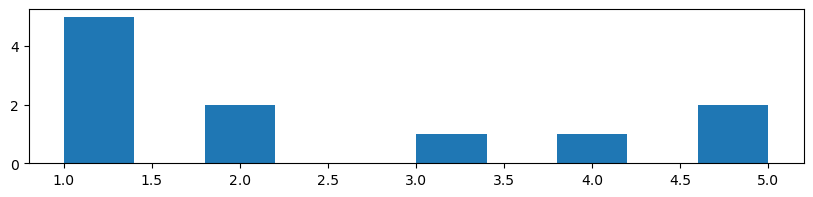

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,2)) #그래프 사이즈 조절 
x=[1,2,3,1,1,1,2,1,4,5,5]
plt.hist(x,bins=10 )
plt.show()

In [3]:
np.random.rand(100000)

array([0.36799382, 0.05137288, 0.75750277, 0.58682012, 0.56745292,
       0.62821534])

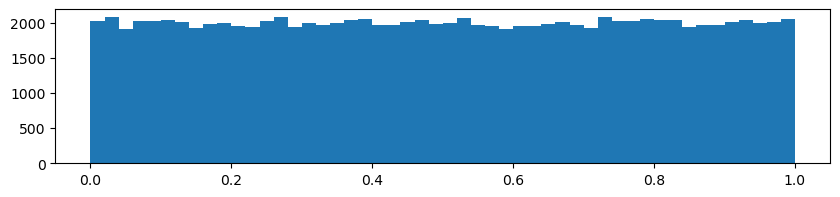

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,2)) #그래프 사이즈 조절 
# x=np.random.random(10000)
# x=np.random.uniform(3,10, 1000000)
x=np.random.rand(100000)
plt.hist(x,bins=50 )
plt.show()

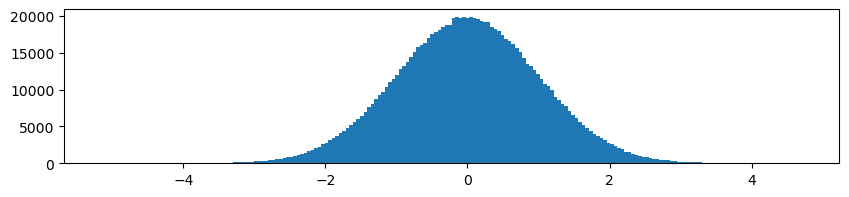

In [30]:
import matplotlib.pyplot as plt # 그래프 사이즈 조절 
plt.figure(figsize=(10,2))
x = np.random.normal(50, 10, 1000000)#정규분포
x = np.random.normal(0,1,1000000)#표준정규분포
x = np.random.randn(1000000)#표준정규분포
plt.hist(x,bins=200 )
plt.show()

In [7]:
#2차원 균등분포 난수 (0~1미만 실수 난수) 배열 
import numpy as np
np.random.seed(3) # seed 값을 맞추면 발생되는 난수가 동일. seed 값을 초기화 하려면 커널 재시작 
np.random.random((2,5)) #2행 5열짜리 2차원 난수 배열 

array([[0.5507979 , 0.70814782, 0.29090474, 0.51082761, 0.89294695],
       [0.89629309, 0.12558531, 0.20724288, 0.0514672 , 0.44080984]])

In [9]:
#2차원 균등분포 난수 (-1~1미만 실수 난수) 배열 
np.random.uniform(-1,1,(2,5))

array([[-0.94024758, -0.08633355,  0.2982881 , -0.44302543,  0.3525098 ],
       [ 0.18172563, -0.95203624,  0.11770818, -0.48149511, -0.16979761]])

In [18]:
#2차원 정규분포 난수 (평균3에 표준편자 1인 난수 )배열 
x=np.random.normal(3,1, size=(2,5))#1행 5열 2차원 배열 
x

array([[2.3971149 , 1.08552796, 4.04814751, 4.33373782, 2.80258532],
       [4.77464503, 2.32527249, 3.15061687, 3.1529457 , 1.93580473]])

In [21]:
# 1차원 균등분포 난수 배열 
np.random.rand(3)
np.random.random(3)

array([0.92672568, 0.83919306, 0.7263195 ])

In [23]:
#1차원 표준정규분포 (평균 0, 표준편차 1인 정규분포)배열 
np.random.randn(3)
np.random.normal(size=3)

array([1.22466464, 0.22929105, 0.71013672])

## 2.4 연속된 값을 갖는 배열 만들기 
- np.arange(from, to, by, dtype):from 부터 to (to미포함) 앞까지 by씩 건너뛴 값을 1차원 배열로 생성
- np.linespace(from, to, num): from부터 to 까지 (to 포함) num개 숫자들을 1차원 배열로 생성 

In [25]:
np.arange(10, 30,5, dtype=np.float32)

array([10., 15., 20., 25.], dtype=float32)

In [28]:
np.arange(0,3,0.3)

array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7])

In [31]:
np.linspace(0, 3, 20) #0부터 같은 간격으로 20개 수를 배열로 생성

array([0.        , 0.15789474, 0.31578947, 0.47368421, 0.63157895,
       0.78947368, 0.94736842, 1.10526316, 1.26315789, 1.42105263,
       1.57894737, 1.73684211, 1.89473684, 2.05263158, 2.21052632,
       2.36842105, 2.52631579, 2.68421053, 2.84210526, 3.        ])

In [32]:
np.linspace(0, 3, 20).reshape(4,5)

array([[0.        , 0.15789474, 0.31578947, 0.47368421, 0.63157895],
       [0.78947368, 0.94736842, 1.10526316, 1.26315789, 1.42105263],
       [1.57894737, 1.73684211, 1.89473684, 2.05263158, 2.21052632],
       [2.36842105, 2.52631579, 2.68421053, 2.84210526, 3.        ]])

In [40]:
x= np.array([0,1,2,3,4,5,6])
#linspace :특정구간에 많은 수의 점을 생성할 때 유용 
x = np.linspace(0,6,100)
y= np.sin(x)

<function matplotlib.pyplot.show(close=None, block=None)>

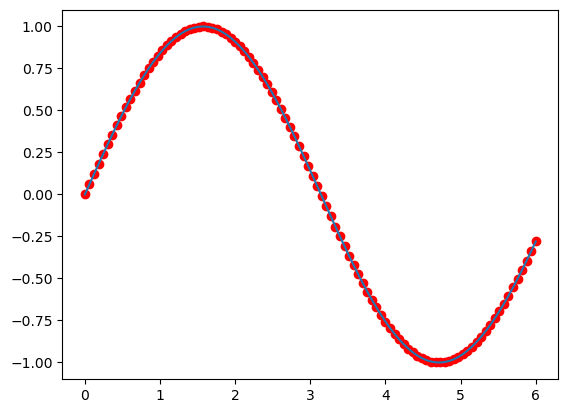

In [44]:

from matplotlib import pyplot as plt
plt.scatter(x,y,c='r') #빨간색 점그래프 
plt.plot(x,y) # 선그래프 
plt.show

## 2.5 배열의 차원 변경 
- reshape (행수, 열수) : 차원 변경된 배열 return  (-1가능 )
- resize ((행수, 열수)) :배열을 차원 변경 (-1 불가)
- ravel(), flatten() : 1차원으로 변경된 배열 return
- T :전치행렬로 변환
- transpose(): 전치행렬로 변환 

※ 실행결과가 출력되면 배열이 수정되지 않고, 실행결과가 없으면 배열이 수정됨

In [46]:
t =np.random.random((2,5))
print(t)
print

array([[0.48887324, 0.92793635, 0.7876182 , 0.48509423, 0.45527936],
       [0.21798577, 0.17721338, 0.07362367, 0.89239319, 0.64017662]])

In [48]:
# t*10 요소별 연산
# round (t*10) : 스칼라 값을 반올림 
a= np.round(t*10)
a

array([[5., 9., 8., 5., 5.],
       [2., 2., 1., 9., 6.]])

In [50]:
a= a.astype(np.int16) # astype()을 이용해서 요소별 타입 변환 
a

array([[5, 9, 8, 5, 5],
       [2, 2, 1, 9, 6]], dtype=int16)

In [52]:
a.reshape(5,2)
a

array([[5, 9, 8, 5, 5],
       [2, 2, 1, 9, 6]], dtype=int16)

In [53]:
a.reshape(5,-1) #해당차원의 크기가 자동 계산 a의 item이 10이니 5행으로 하면 2열로 자동 계산 

array([[5, 9],
       [8, 5],
       [5, 2],
       [2, 1],
       [9, 6]], dtype=int16)

In [56]:
a.reshape(-1,2)
a

array([[5, 9, 8, 5, 5],
       [2, 2, 1, 9, 6]], dtype=int16)

In [60]:
a.resize((2,5)) #a 를 바꿈 
a.resize(2,5)
a

array([[5, 9, 8, 5, 5],
       [2, 2, 1, 9, 6]], dtype=int16)

In [ ]:
a.resize(-1) #resize 함수에는 -1불가 

In [61]:
a.ravel() # 실행결과가 나오면 a는 안바뀌고 결과가 나오면 바뀐것임 

array([5, 9, 8, 5, 5, 2, 2, 1, 9, 6], dtype=int16)

In [62]:
a.flatten()

array([5, 9, 8, 5, 5, 2, 2, 1, 9, 6], dtype=int16)

In [63]:
a

array([[5, 9, 8, 5, 5],
       [2, 2, 1, 9, 6]], dtype=int16)

In [64]:
a.T #a 의 전치행렬 (행과 열을 뒤바꾼 행렬  ex. 0행1열 -> 1행 0열)

array([[5, 2],
       [9, 2],
       [8, 1],
       [5, 9],
       [5, 6]], dtype=int16)

In [67]:
a.transpose()#a의 전치행렬

array([[5, 2],
       [9, 2],
       [8, 1],
       [5, 9],
       [5, 6]], dtype=int16)

In [68]:
a

array([[5, 9, 8, 5, 5],
       [2, 2, 1, 9, 6]], dtype=int16)

## 2.6 배열 인쇄

In [72]:
print(np.arange(1001)) # item갯수가 1000개까지만 나와 . 배열이 너무 크면 안 나옴 

[   0    1    2 ...  998  999 1000]


In [74]:
np.get_printoptions()['threshold']#출력되는 limit 

1000

In [77]:
#배열이 너무 커서 인쇄할 수 없는 경우 threshold값을 자동으로 건너뛰고 모서리 부분만 나옴
# 넘파이의 인쇄 옵션 변경 (인쇄할 사이즈를 조정 )
np.set_printoptions(threshold=10000)#배열 10000개까지 출력하도록 옵션셋팅 
np.set_printoptions(threshold=np.inf) #np.inf: 무한대 
import sys 
np.set_printoptions(threshold=sys.maxsize)

In [76]:
np.arange(100000).reshape(1000, 100)

array([[    0,     1,     2, ...,    97,    98,    99],
       [  100,   101,   102, ...,   197,   198,   199],
       [  200,   201,   202, ...,   297,   298,   299],
       ...,
       [99700, 99701, 99702, ..., 99797, 99798, 99799],
       [99800, 99801, 99802, ..., 99897, 99898, 99899],
       [99900, 99901, 99902, ..., 99997, 99998, 99999]])

In [78]:
sys.maxsize

9223372036854775807

In [ ]:
# 다시 원상복귀하려면 커널을 다시 시작하던지 theshold를 바꾸면 됨 아니면 아래와 같이 함 
import numpy as np 
np.set_print

## 2.7 기본연산 동작 

### 1) 배열의 요소별 연산 

In [85]:
a= np.array([10,20,30,40], dtype=np.int8)
b= np.arange(4) #np.int32 
print(a) #배열을 print함수에 넣으면 array와 ,(콤마)가 안나옴 
print(b)
print(a.dtype, b.dtype)

[10 20 30 40]
[0 1 2 3]
int8 int32


In [82]:
print([1,2,3])


[1, 2, 3]


In [87]:
c= a+b # 요소별 +연산(dtype은 튼거로, 정수와 실수연산은 실수로)

print(c)
print(c.dtype)

[10 21 32 43]
int32


In [90]:
a*2

array([20, 40, 60, 80], dtype=int8)

In [91]:
a*b #요소별 연산시 dtype이 큰쪽인 int32 

array([  0,  20,  60, 120])

In [92]:
a** b

array([    1,    20,   900, 64000], dtype=int32)

In [93]:
a < 40

array([ True,  True,  True, False])

In [99]:
print(a[[1,2,3]]) #index를 list로 
print(a[[True, False, True, False]]) #boolean index False는 안나옴 index모든값에 대한 t/f 다 넣어줘야함 
print(a[[0,2]])

[20 30 40]
[10 30]
[10 30]


In [100]:
#a 배열에서 40미만인 데이터만 추출하려면 boolean index사용 
a[a<40]

array([10, 20, 30], dtype=int8)

In [101]:
#a 배열에서 40미만인 데이터의 index 
np.where(a<40)

(array([0, 1, 2], dtype=int64),)

### 2)행렬의 곱 (@, dot 함수) cf.*(요소별 곱)
- 2차원 배열은 행렬로 취급
- pdf18page 

In [103]:
A = np.array([[1,1], [0,1]])
B=np.array([[2,0], [3,4]])
A,B

(array([[1, 1],
        [0, 1]]),
 array([[2, 0],
        [3, 4]]))

In [105]:
print('요소별 곱 A*B=', A*B, sep="\n")
print('행렬 곱 A@B=', A@B, sep="\n")
print('행렬곱 A.dot(B) =', A.dot(B), sep="\n")

요소별 곱 A*B=
[[2 0]
 [0 4]]
행렬 곱 A@B=
[[5 4]
 [3 4]]
행렬곱 A.dot(B) =
[[5 4]
 [3 4]]


In [108]:
# pdf 19  
# ①
a = np.array([[1,2],[3,4]])
b = np.array([[-1,-1],[1,1]])
print(a@b, b@a, sep="\n")

[[1 1]
 [1 1]]
[[-4 -6]
 [ 4  6]]


In [109]:
# ②
a = np.array([[1,2],[3,4]])
b = np.array([6,7])
print(a@b, b@a, sep="\n")

[20 46]
[27 40]


In [110]:
#③
a = np.array([6,7])
b = np.array([[1,2],[3,4]])
print(a@b, b@a, sep="\n")

[27 40]
[20 46]


In [111]:
#④ 
a = np.array([[2,0],[3,4]])
b = np.array([[1,0],[0,1]])
print(a@b, b@a, sep="\n") 

[[2 0]
 [3 4]]
[[2 0]
 [3 4]]


In [116]:
#⑤
a = np.array([[1,2,3],[4,5,-1]])
b = np.array([[1,2],[1,2],[3,2]])
print(a@b, b@a, sep="\n")

[[12 12]
 [ 6 16]]
[[ 9 12  1]
 [ 9 12  1]
 [11 16  7]]


In [118]:
# a@b != b@a 
#a@단위행렬 == 단위행렬@a ; 단위행렬에서는 행렬곱의 교환번칙이 성립 
A = np.array([[1,0],
              [0,1]]) #2행2열짜리 단위행렬
B = np.array([[2,0],
             [3,4]])
print('A@B=', A@B, sep='\n')
print('B@A=', B@A, sep='\n')

A@B=
[[2 0]
 [3 4]]
B@A=
[[2 0]
 [3 4]]


In [119]:
#2행2열 단위 행렬 만드는 법 
np.eye(2)

array([[1., 0.],
       [0., 1.]])

### 3)복합대입연산자 사용 (+=, -=,...)
- a += b는 a=a+b와 다소 다르게 작동 

In [142]:
a = np.ones((2,3),dtype='int8') # int8 로 읽어라는 뜻. 범위 -128~127
b = np.random.random((2,3))#float64

print(a,b,sep="\n")

[[1 1 1]
 [1 1 1]]
[[0.26034507 0.69197751 0.89557033]
 [0.34068848 0.0646732  0.86411967]]


In [143]:
a +=5 # a= a+5 
a[0,0]=128
a

array([[-128,    6,    6],
       [   6,    6,    6]], dtype=int8)

In [125]:
a += 255 #공간이 부족 하면 a에 오류가 생김 
a

array([[5, 5, 5],
       [5, 5, 5]], dtype=int8)

In [129]:
a = a+255 #a +255 를 요소별로 계산하여 새로운 a배열을 생성하여 할당 
a

array([[1025, 1025, 1025],
       [1025, 1025, 1025]], dtype=int16)

In [131]:
b += a #b+a 를 기존의 b에 넣는다
b

array([[2050.4789783 , 2050.27478051, 2050.65222313],
       [2050.95644951, 2050.43552056, 2050.07013251]])

In [132]:
a += b # a+b(float64) 를 기존의 a에 넣는다
a


UFuncTypeError: Cannot cast ufunc 'add' output from dtype('float64') to dtype('int16') with casting rule 'same_kind'

In [133]:
# 스칼라 데이터에서는 문제되지 않음. 배열일때만 문제가 됨 
x=5
y=5.7
x+=y
x

10.7

### 4) 배열요소별 집계
- sum, min, max, mean, var(분산), std(표준편차) 

In [144]:
a = np.array([[2,2,2,3],
              [4,3,2,1]])

In [138]:
print('전체 합:', a.sum(), np.sum(a))
print('전체 최소값:', a.min(), np.min(a))
print('전체 최대값:', a.max(), np.max(a))
print('전체 평균:', a.mean(), np.mean(a))
print('전체 분산:', a.var(), np.var(a))
print('전체 표준편차:', a.std(), np.std(a))

전체 합: 19 19
전체 최소값: 1 1
전체 최대값: 4 4
전체 평균: 2.375 2.375
전체 분산: 0.734375 0.734375
전체 표준편차: 0.8569568250501305 0.8569568250501305


In [139]:
# 분산에 루트씌우면 표준편차 
import math 
math.sqrt(a.var())#math.sqrt(스칼라값)

0.8569568250501305

### 5)배열 축별 집계

- 축별 sum, min, max,mean,var,std 
 * 1차원일 때 axis0=열
 * 2차원일때 axis0=행, axis1=열
 * 3차원일때 axis0=면, axis1=행, axis2=열)


In [145]:
a

array([[2, 2, 2, 3],
       [4, 3, 2, 1]])

In [148]:
# axis=1(1축) 들의 합:행을 고정하고 1축 (열들)의 합

print('a의 행별 합:', a.sum(axis=1), np.sum(a,axis=1))

a의 행별 합: [ 9 10] [ 9 10]


In [169]:
#axis=1 을 고정하고 0축(행들)의 합 
print ('a의 열별 합:', a.sum(axis=0), np.sum(a, axis=0))

a의 열별 합: [6 5 4 4] [6 5 4 4]


In [170]:
#3차원 배열의 집계 

b= np.arange(24).reshape(2,3,4) #2면 3행 4열 
b

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [171]:
b.sum(axis=0) #행과 열은 고정하고 면(axis0 0축)의 합 0,0,0+1,0,0 

array([[12, 14, 16, 18],
       [20, 22, 24, 26],
       [28, 30, 32, 34]])

In [172]:
b.sum(axis=1) #면과 열은 고정하고 행이 합 0,0,0+0, 1,1+1,2,0

array([[12, 15, 18, 21],
       [48, 51, 54, 57]])

In [173]:
b.sum(axis=2)# 면과 행은 고정하고 열들의 합 

array([[ 6, 22, 38],
       [54, 70, 86]])

## 2.8 요소별 계산하는 범용함수들 
- np.sqrt(배열): 제곱근 /math.sqrt(스칼라변수)
- np.add(A,B,C): C = np.add(A,B)와 동일 / C=A+B와 동일의미 
- np.multiply(A,B,C) : C =np.multiply(A,B) / C= A*B와 동일의미
- np.subtract(A,B,C) : C =np.subtract(A,B) /C=A-B와 동일의미 

In [174]:
a=np.array([1,4])
b=np.array([3,4])
c=np.empty(2) 
a,b,c 

(array([1, 4]), array([3, 4]), array([1.06099790e-313, 8.48798317e-314]))

In [177]:
# math.sqrt(a)
np.sqrt(a)

array([1., 2.])

In [178]:
np.add(a,b,c) # c=np.add(a,b),c=a+b 
c=a+b 
c

array([4., 8.])

In [ ]:
np.subtract(a,b,c) # 
c=
c

## 2.9 브로드케스팅 
- 서로다른 크기의 배열 간 연산을 수행 할 수 있도록 해주는 강력한 기능 

In [186]:
# 1차원 배열인 경우 (pdf 26p)
a = np.array([1,2,3])
b=np.array([2])
print(a+b)
print(np.add(a,b))

[3 4 5]
[3 4 5]


In [184]:
# 1차원 배열인 경우 브로드케스팅  
a = np.array([1,2,3])
b=2
print(a+b)
print(np.add(a,b))

[3 4 5]
[3 4 5]


In [185]:
a*b 

array([2, 4, 6])

In [187]:
#2차원 배열인 경우의 브로드케스팅 
a=np.array([[0,0,0], 
           [10,10,10],
           [20,20,20],
           [30,30,30]]) # 4x3 배열
b=np.array([1,2,3]) #3열짜리 배열 
a+b 

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

In [189]:
#2차원 배열인 경우의 브로드케스팅 
a= np.array([[0,0,0], 
           [10,10,10],
           [20,20,20],
           [30,30,30]]) # 4x3 배열

b=np.array([[0],
           [1],
           [2],
           [3]]) #4X1열짜리 배열 
#브로드케스팅되서 아래와 같이 연산 
#b=np.array([[0,0,0],
#           [1,1,1],
 #          [2,2,2],
 #          [3,3,3]])
a+b 

array([[ 0,  0,  0],
       [11, 11, 11],
       [22, 22, 22],
       [33, 33, 33]])

In [190]:
# 브로드캐스팅을 할 수 없는 예 (pdf 28p)
a =np.array([0,10,20,30])
b=np.array([1,2,3])
a+b 

ValueError: operands could not be broadcast together with shapes (4,) (3,) 

In [197]:
a

array([ 0, 10, 20, 30])

In [200]:
#np.newaxis연산자를 이용하여 배열에 새로운 축을 추가 => 2차원
A=a[:, np.newaxis]
#A= a.reshape(-1,1)
#A= np.expand_dims(a,axis=1)
A
#np.array([[0],
 #        [10],
#         [20],
#         [30]])


array([[ 0],
       [10],
       [20],
       [30]])

In [203]:
# a와 b의 모든 쌍 조합에 계산하고 싶을 때 브로드케스팅 특성 이용, np.ix_함수 이용 A+b 
A+b

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

In [204]:
ax, bx=np.ix_(a,b)#n개의 1차원을 입력받아 각 n차원인 n개의 출력을 반환
ax+bx

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

# 3절.배열 합치기/배열분리하기
[numpy API Docs](https://numpy.org/doc/stable/reference/index.html)
- 슬라이싱 
- 두배열을 합치는 함수 
- r_, c_ 
- 하나의 배열을 여러개 작은 배열로 분리하는 함수 
## 3.1다차원 배열 인덱싱과 슬라이싱 

In [205]:

b=np.arange(20).reshape(5,4)
b

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19]])

In [206]:
b[2,1]#없는 인덱싱시 에러 

9

In [207]:
#모든 행의 마지막 열 앞까지 (종속변수를 제외하는 용도)
b[:,:-1]

array([[ 0,  1,  2],
       [ 4,  5,  6],
       [ 8,  9, 10],
       [12, 13, 14],
       [16, 17, 18]])

In [208]:
b[..., :-1] # :이나 ... 이나 똑같음, 선행축은 생략 불가능 ex. b[, :-1] 에러


array([[ 0,  1,  2],
       [ 4,  5,  6],
       [ 8,  9, 10],
       [12, 13, 14],
       [16, 17, 18]])

In [209]:
# 0~2행가지 모든 열 (모든 열의 경우, 생략가능 == 모든 열의 경우, 후행축은 생략가능)
b[0:3,:]
b[0:3, ...]
b[0:3]

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [210]:
b[, :-1]

SyntaxError: invalid syntax (962414769.py, line 1)

## 3.2 두배열을 쌓아 합치는 함수
- vstack(tup): 아래로 추가하는 방식 
- hstack(tup): 옆으로 추가하는 방식 
- dstack(tup): 마지막축(열)을 쌓아 합침 (차원증가) 
- 

In [213]:
c= np.array([1,2,3])
d=np.array([4,5,6])
v=np.vstack((c,d))
print('vstack으로 아래로 합치기:', v, v.shape, sep='\n')
h=np.hstack((c,d))
print('hstack으로 옆으로 합치기:', h, h.shape, sep='\n')
d=np.dstack((c,d))#reshape(3,2)
print('dstack으로 depth로 합치기:', d, d.shape, sep='\n')

vstack으로 아래로 합치기:
[[1 2 3]
 [4 5 6]]
(2, 3)
hstack으로 옆으로 합치기:
[1 2 3 4 5 6]
(6,)
dstack으로 depth로 합치기:
[[[1 4]
  [2 5]
  [3 6]]]
(1, 3, 2)


In [217]:
c=np.arange(24).reshape(2,3,4)
c

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [218]:
a,b=c
a,b

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]),
 array([[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]))

In [219]:
#수직으로 합치기
np.vstack((a,b))

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

In [ ]:
np.concatenate((a,b), axis=0)#axis=0 이 기본값 

In [220]:
#수평으로 합치기
np.hstack((a,b))

array([[ 0,  1,  2,  3, 12, 13, 14, 15],
       [ 4,  5,  6,  7, 16, 17, 18, 19],
       [ 8,  9, 10, 11, 20, 21, 22, 23]])

In [221]:
np.concatenate((a,b), axis=1)

array([[ 0,  1,  2,  3, 12, 13, 14, 15],
       [ 4,  5,  6,  7, 16, 17, 18, 19],
       [ 8,  9, 10, 11, 20, 21, 22, 23]])

In [224]:
np.dstack((a,b))


array([[[ 0, 12],
        [ 1, 13],
        [ 2, 14],
        [ 3, 15]],

       [[ 4, 16],
        [ 5, 17],
        [ 6, 18],
        [ 7, 19]],

       [[ 8, 20],
        [ 9, 21],
        [10, 22],
        [11, 23]]])

- column_stack(tup): 1차원 배열을 2차원 배열의 열단위 합침 
- row_stack(tup) : 행단위로 합침 ==vstack()

In [226]:
a=np.array([1,2,3,4])
b=np.array([5,6,7,8])
c=np.array([9,10,11,12])
np.column_stack((a,b,c))

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [228]:
np.hstack((a[:,np.newaxis],b[:,np.newaxis], c[:,np.newaxis]))

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [229]:
np.row_stack((a,b,c))

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [230]:
np.vstack((a,b,c))

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

- stack(tup, axis=n):axis속성에 따라 배열을 합침. axis은 음수차원 0번째 차원 0행/1열/-1열 

In [231]:
c=np.arange(24).reshape(2,3,4)
a,b=c
a,b

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]),
 array([[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]))

In [232]:
np.stack((a,b),axis=0)#2차원배열끼리 stack을 하면 3차원으로 axis=0 면으로 합하기

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [233]:
np.stack((a,b),axis=1) #axis=1 행끼리 합치기 

array([[[ 0,  1,  2,  3],
        [12, 13, 14, 15]],

       [[ 4,  5,  6,  7],
        [16, 17, 18, 19]],

       [[ 8,  9, 10, 11],
        [20, 21, 22, 23]]])

In [234]:
np.stack((a,b),axis=2) #a의 행과 b의 행이 열로 합치기 

array([[[ 0, 12],
        [ 1, 13],
        [ 2, 14],
        [ 3, 15]],

       [[ 4, 16],
        [ 5, 17],
        [ 6, 18],
        [ 7, 19]],

       [[ 8, 20],
        [ 9, 21],
        [10, 22],
        [11, 23]]])

## 3.3 r_, c_ 
- 나열객체 

In [235]:
a= np.array([1,2,3,4])
b=np.array([5,6,7,8])
c=np.array([9,10,11,12])

In [238]:
np.r_[a,b,c]


array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [239]:
np.r_[[a],[b],[c]]

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [240]:
np.c_[a,b,c] #컬럼단위로 쌓아줌 (c_와 column_stack이 가장 많이 사용)

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [241]:
np.column_stack((a,b,c))

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

## 3.4 배열 분리하는 함수 
- vsplit(ary, 정수나 벡터) : 첫번째 축(axis0-2차원의 경우 가로축)을 따라 분할
- hsplit(ary, 정수나 벡터) : 두번째 축(axis1 - 2차원의 경우 세로축)을 따라 분할
- split(ary, 정수나 벡터, axis)
---
- array_split(ary, 정수나 벡터, axis)
- **split과 차이점은 나눠지지 않은 정수로도 사용 가능** 

In [243]:
a=np.arange(12).reshape(3,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [245]:
a_split =np.vsplit(a,3) #가로축(axis0축)을 따라 3개로 분할
a_split

[array([[0, 1, 2, 3]]), array([[4, 5, 6, 7]]), array([[ 8,  9, 10, 11]])]

In [246]:
a_split =np.vsplit(a,[2])#가로축(axis0축)을 따라 2번째 index앞에서 분할 
a_split

[array([[0, 1, 2, 3],
        [4, 5, 6, 7]]),
 array([[ 8,  9, 10, 11]])]

In [248]:
np.hsplit(a,2) #a를 두개로 세로축으로 분리 

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

In [249]:
np.hsplit(a,[3])# a를 3번째 index열 기준으로 분리 

[array([[ 0,  1,  2],
        [ 4,  5,  6],
        [ 8,  9, 10]]),
 array([[ 3],
        [ 7],
        [11]])]

In [250]:
np.hsplit(a,3)

ValueError: array split does not result in an equal division

In [251]:
np.split(a,3, axis=0)#0축으로 분리. 2차원에서의 vsplit(a,3)

[array([[0, 1, 2, 3]]), array([[4, 5, 6, 7]]), array([[ 8,  9, 10, 11]])]

In [252]:
np.split(a,2,axis=1) #1축으로 분리. 2차원에서의 hsplit(a,2)

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

In [253]:
np.array_split(a,3,axis=1) #나눠지지 않는 정수 갯수를 알아서 나눠 

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2],
        [ 6],
        [10]]),
 array([[ 3],
        [ 7],
        [11]])]

In [255]:
np.split(a,[1,2], axis=1) #1번째 index열 2번째 index열을 기준으로 나눠 

[array([[0],
        [4],
        [8]]),
 array([[1],
        [5],
        [9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

# 4절. 복사와 뷰
## 4.1할당 

In [141]:
#스칼라 변수
a=10
b-a
print('a와 b의 주소:', id(a), id(b))
print('수정후 a와 b의 데이터:', a, b)

a와 b의 주소: 1580959400464 1580959400112
수정후 a와 b의 데이터: 10 -1


In [142]:
# 배열 
a = np.arange(12)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [143]:
b=a 
#b =np.array(a, copy=False)와 같음
a.shape, type(a), a.ndim, id(a)

((12,), numpy.ndarray, 1, 1581077777264)

In [ ]:
a.shape, type(a), a.ndim, id(a)

In [144]:
a is b 

True

In [145]:
a ==b # 요소별 비교 

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [147]:
np.all(a==b) # np.all() array 배열 안에 모든 값이 True인지 여부 

True

In [148]:
b.shape = (3,4)

In [149]:
a.shape, type(a), a.ndim, id(a)

((3, 4), numpy.ndarray, 2, 1581077777264)

In [150]:
a.shape

(3, 4)

In [151]:
a


array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

## 4.2 뷰(View): 얕은 복사 

In [153]:
a = np.arange(12).reshape(3,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [155]:
c = a.view() #얕은 복사 
c

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [156]:
id(a), id(c)

(1581079615920, 1581091006832)

In [157]:
a==c

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [158]:
np.all(a==c)

True

In [159]:
a is c

False

In [160]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [163]:
c.shape =(2,6)
c

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11]])

In [164]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [168]:
#배열 복사본 c의 특정 요소만 변경 
c[1,::2]=-99
c

array([[  0,   1,   2,   3,   4,   5],
       [-99,   7, -99,   9, -99,  11]])

In [173]:
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

In [204]:
#슬라이싱이 될때 뷰가 반환됨 (shape, dtype 변경 외에는 원본도 변경 )
a= np.array([[99,88,77,85],
            [88,71,77,77],
           [99,99,99,99],])
X = a[:,:-1]
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

In [205]:
X = a[:,:-1].copy()
X

array([[99, 88, 77],
       [88, 71, 77],
       [99, 99, 99]])

In [203]:
X[0:2, -1] =1
X[-1,-1]=-1
X

array([[ 1,  1,  1],
       [ 1,  1,  1],
       [ 1,  1, -1]])

In [181]:
a

array([[99, 88,  1, 85],
       [88, 71,  1, 77],
       [99, 99, -1, 99]])

## 4.3 깊은 복사

In [188]:
a=np.array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

In [200]:
# x = a[:,:-1]# 얕은복사  (view 생성)
X= a[:,:-1].copy() #깊은 복사 ★ 주의 
X

array([[99, 88, 77],
       [88, 71, 77],
       [99, 99, 99]])

In [201]:
X[:,0:2]=1
X[-1,-1]=-1
X

array([[ 1,  1, 77],
       [ 1,  1, 77],
       [ 1,  1, -1]])

In [202]:
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

# 5절. 고급인덱싱
## 5.1 인덱스 배열로 인덱싱

In [256]:
a=np.arange(12)**2
a

array([  0,   1,   4,   9,  16,  25,  36,  49,  64,  81, 100, 121])

In [257]:
a[[0,5,9]]

array([ 0, 25, 81])

In [258]:
a[[0,1,1,5]]

array([ 0,  1,  1, 25])

In [260]:
#인덱싱하기 위한 값을 1차원 배열
idx_ary=np.array([0,5,5,8])
a[idx_ary]#결과는 인덱싱 배열(4열짜리 1차원 배열)의 형태로 따라감 

array([ 0, 25, 25, 64])

In [261]:
#인덱싱하기 위한 값을 2차원 배열
idx_ary=np.array([[0,5],
                 [5,8]])
a[idx_ary]

array([[ 0, 25],
       [25, 64]])

In [262]:
#인덱스 뱌열을 이용한 a수정 
a[idx_ary]=-9
a

array([ -9,   1,   4,   9,  16,  -9,  36,  49,  -9,  81, 100, 121])

In [266]:
a[idx_ary]+= 9 # 0번째, 5번째, 8번째 . 복합대입연산자가 5번째는 한번만
a

array([ 27,   1,   4,   9,  16,  27,  36,  49,  27,  81, 100, 121])

## 5.2 argmax: 최대값이 있는 인덱스 

In [267]:
data =np.sin(np.arange(20).reshape(5,4))
data

array([[ 0.        ,  0.84147098,  0.90929743,  0.14112001],
       [-0.7568025 , -0.95892427, -0.2794155 ,  0.6569866 ],
       [ 0.98935825,  0.41211849, -0.54402111, -0.99999021],
       [-0.53657292,  0.42016704,  0.99060736,  0.65028784],
       [-0.28790332, -0.96139749, -0.75098725,  0.14987721]])

In [270]:
#각열별 큰값이 있는 index 행수 
ind=data.argmax(axis=0) # 0행1행2행3행중 가장 큰값이 있는 index행수 
ind

array([2, 0, 3, 1], dtype=int64)

In [273]:
#0열에서 제일 큰 행값, 1열에서 제일 큰 행값
data[ind[0],0],data[ind[1],1]

(0.9893582466233818, 0.8414709848078965)

In [278]:
data_col_max = data[ind, range(data.shape[1])]
data_col_max 

array([0.98935825, 0.84147098, 0.99060736, 0.6569866 ])

In [277]:
data.max(axis=0)

array([0.98935825, 0.84147098, 0.99060736, 0.6569866 ])

In [280]:
# 두 배열이 같은지 여부 
np.all(data_col_max==data.max(axis=0))

True

## 5.3 논리 배열을 이용한 인덱싱 
- booleanindex 

In [153]:
a = np.arange(20)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

In [154]:
a%2==0

array([ True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False])

In [155]:
a[a%2==0]# 배열에서 원하는 조건의 item만 추출

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [286]:
a[a>=10]

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19])

# 6절. 선형대수 
- 2차원 배열을 행렬
    * 행렬곱:@, np.dot()
    * 역행렬: 어떤 행렬과 역행렬을 행렬곱하면 결과가 단위행렬
    * 전치행렬 : X.T, X.transpose() 행과 열을 바꿔
    * 단위행렬 : np.eye(n) n행n열 단위행렬 

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQw4Gz9f4GqEYWd65xoFXRK-DENfo6jE42LCdguUd8y&s=10" width="400" style="float:left">

In [4]:
import numpy as np 
a = np.array([[1,2],
              [3,4]])
a

array([[1, 2],
       [3, 4]])

In [7]:
1/(4-6)* np.array([[4,-2],[-3,1]])

array([[-2. ,  1. ],
       [ 1.5, -0.5]])

In [8]:
#a 의 역행렬 : a의 역행렬 a @ a의 역행렬 == 단위행렬
np.linalg.inv(a)

array([[-2. ,  1. ],
       [ 1.5, -0.5]])

In [9]:
a @ np.linalg.inv(a), np.linalg.inv(a)@ a

(array([[1.00000000e+00, 1.11022302e-16],
        [0.00000000e+00, 1.00000000e+00]]),
 array([[1.0000000e+00, 4.4408921e-16],
        [0.0000000e+00, 1.0000000e+00]]))

In [11]:

np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [13]:
a@ np.eye(2), np.eye(2)@ a,a

(array([[1., 2.],
        [3., 4.]]),
 array([[1., 2.],
        [3., 4.]]),
 array([[1, 2],
        [3, 4]]))

## 6.1 단변량 회귀분석(선형 연립방정식):독립변수1, 데이터 2개 

In [26]:
import numpy as np 
x=np.array([2,4]) # 독립변수(입력데이터)
y=np.array([40,60]) # 종속변수(타겟변수)
Y= y.reshape(-1, 1)
Y=y[:, np.newaxis]
Y=np.expand_dims(y, axis=1)
Y=y[:, None]
X=np.column_stack((x, np.ones(len(x))))
X, Y

(array([[2., 1.],
        [4., 1.]]),
 array([[40],
        [60]]))

In [27]:
#    X      @ wb  = Y
# X의 역행렬 @ X @ wb = X의 역행렬 @ Y 
# (X의 역행렬 @ X) @ wb = X의 역행렬 @ Y 
#        단위행렬 @ wb= X의 역행렬 @ Y
#wb = X의 역행렬 @Y
wb = np.linalg.inv(X) @Y
wb


array([[10.],
       [20.]])

In [37]:
wb[0], wb[1] # weight, bias 

(array([10.]), array([20.]))

In [39]:
x_=np.linspace(0,10,100)
h=wb[0]*x_ +wb[1] #예측값
# h= np.add(np.multiply(wb[0],x_), wb[1]) #데이터가 많고 식이 복잡할 경우 범용함수 사용 추천

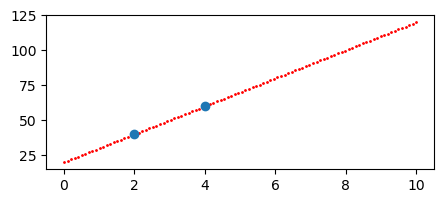

In [43]:
import matplotlib.pyplot as plt 
plt.figure(figsize =(5,2)) #현재셀의 그래프 사이즈 조정
#plt.rcParams['figure.figure']
plt.scatter(x_, h, c='r', s=1) # 점그래프 
plt.scatter(x,y)
plt.show()

In [44]:
np.linalg.solve(X,Y)# X가 정방행렬일 경우 

array([[10.],
       [20.]])

## 6.2 단변량 회귀분석(선형 연립방정식):독립변수1, 데이터 n개 

In [46]:
import numpy as np 
a=np.array([[2,1], [3,1],[4,1], [5,1]])
a #정방 행렬이 아님 

array([[2, 1],
       [3, 1],
       [4, 1],
       [5, 1]])

In [ ]:
#역행렬(정방행렬 일때만 역행렬 가능)
#np.linalg.inv(a)

In [47]:
a.T # 전치행렬 

array([[2, 3, 4, 5],
       [1, 1, 1, 1]])

In [48]:
a.T @ a # a가 정방행렬이 아니면 전치 행렬을 곱하여 정방 행렬을 만듦 

array([[54, 14],
       [14,  4]])

In [49]:
a@a.T

array([[ 5,  7,  9, 11],
       [ 7, 10, 13, 16],
       [ 9, 13, 17, 21],
       [11, 16, 21, 26]])

In [50]:
np.linalg.inv(a.T@a) # a.T @ a의 역행렬 

array([[ 0.2, -0.7],
       [-0.7,  2.7]])

In [51]:
np.linalg.inv(a.T@a) @ a.T @a

array([[ 1.00000000e+00,  9.43689571e-16],
       [-2.22044605e-15,  1.00000000e+00]])

In [71]:
x = np.array([32, 64, 96, 118, 126, 144, 152.5, 158]) # 독립변수(입력데이터)
y = np.array([18, 24, 61.5, 49, 52, 105, 130.3, 125]) # 종속 변수 타겟데이터 
X=np.column_stack((x,np.ones(8)))
X=np.c_[x,np.ones(len(x))] #★
X=np.dstack((x,np.ones(len(x)))).reshape(-1,2)
print(X)
Y= y[:,np.newaxis]
Y=y[:,None]
Y=np.expand_dims(y,axis=1)
Y=y.reshape(-1,1) #★
print(Y)

[[ 32.    1. ]
 [ 64.    1. ]
 [ 96.    1. ]
 [118.    1. ]
 [126.    1. ]
 [144.    1. ]
 [152.5   1. ]
 [158.    1. ]]
[[ 18. ]
 [ 24. ]
 [ 61.5]
 [ 49. ]
 [ 52. ]
 [105. ]
 [130.3]
 [125. ]]


In [72]:
#        X @ wb=Y
# X의 전치행렬 X.T @  X @ wb=X.T @Y
# X.T @ X의 역행렬 @ (X.T @ X) @ wb = X.T @ X의 역행렬 @X.T @Y
# [X.T @ X의 역행렬 @ (X.T @ X) ]@ wb = X.T @ X의 역행렬 @X.T @Y

# X.T @ X의 역행렬 @X.T @Y

In [78]:
wb=np.linalg.inv(X.T@X)@(X.T@Y)
wb

array([[ -0.4],
       [ 20. ],
       [-20. ]])

In [74]:
h = wb[0]* x + wb[1] #도출된 회귀식 (y=w*x+b) 으로 계산된 예측값 

In [75]:
print('독립변수:',x)
print('실제값:',y)
print('예측값:',h)

독립변수: [ 32.   64.   96.  118.  126.  144.  152.5 158. ]
실제값: [ 18.   24.   61.5  49.   52.  105.  130.3 125. ]
예측값: [  1.20701424  29.20481464  57.20261504  76.45110282  83.45055292
  99.19931565 106.63623138 111.44835332]


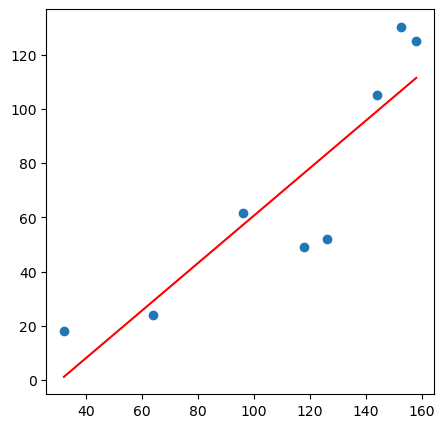

In [76]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(5,5))
#plt.rcParams['figure.figsize']=(5,2)
plt.scatter(x,y)
# plt.scatter(x,h, c='r')  점그래프 
plt.plot(x,h,c='r')#선그래프 

## 6.3 다변량 회귀분석(선형 연립방정식):독립변수 n개, 데이터 n개 

In [77]:
x1=np.array([60,65,55])
x2=np.array([5.5, 5.0, 6.0])
x3=np.array([1,0,1])
y= np.array([66,74,78])
X= np.column_stack((x1, x2,x3))
X=np.c_[x1,x2,x3]
print(X)
Y = y.reshape(-1,1) # y[:, np.newaxis]
print(Y)

[[60.   5.5  1. ]
 [65.   5.   0. ]
 [55.   6.   1. ]]
[[66]
 [74]
 [78]]


In [ ]:
# X@W =Y
# X의 역행렬 X@W =X의 역행렬 @Y
#ㅉ = X의 역행렬 @Y

In [69]:
W=np.linalg.inv(X) @Y 
W

array([[ -0.4],
       [ 20. ],
       [-20. ]])

In [70]:
# 80kg , 6.5ft, No(0)의 수명은 ? 

80*W[0]+6.5*W[1]+0*W[2]

array([98.])

# 7절. 연습문제 
## 실습형 

In [85]:
from sklearn import datasets # sklearn 패키지(머신러닝 및 전처리)안의 datasets 모듈을 load
iris = datasets.load_iris()
iris_data = iris['data']
print(type(iris)) # 딕셔너리로 부터 상속받은 타입
iris_data=iris.data
iris_data[0,:]#0행만
iris_data[0,...]#0행만
iris_data[0, ]#0행만
iris_data[0]#0행만

<class 'sklearn.utils._bunch.Bunch'>


array([5.1, 3.5, 1.4, 0.2])

In [86]:
print(iris.target) #종속변수 (타겟변수 )
print(iris.target_names)#종속 변수가 뜻하는 종의 이름 

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
['setosa' 'versicolor' 'virginica']


In [89]:
# 인덱스 배열을 이용한 원 데이터의 종속변수 

iris.target_names[iris.target][::50]

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [145]:
iris_data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [143]:
# 실습형 1. iris_data 의 각 변수별 평균 (열변 평균)  배열 축결집계 
avr= iris_data.mean(axis=0)
avr

array([5.84333333, 3.05733333, 3.758     , 1.19933333])

In [104]:
# 실습형 2. 처음 다섯개 행 
iris_data[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [109]:
# 실습형 3. 처음 다섯개 행의 마지막 열만 제외 
A= iris_data[:5, :-1]
A

array([[5.1, 3.5, 1.4],
       [4.9, 3. , 1.4],
       [4.7, 3.2, 1.3],
       [4.6, 3.1, 1.5],
       [5. , 3.6, 1.4]])

In [111]:
# 실습형 4 처음 5개 행의 마지막 열만 출력
B=iris_data[:5, 3]
B

array([0.2, 0.2, 0.2, 0.2, 0.2])

In [151]:
# 실습형 5   3번 배열과 4번 배열을 원래 모양이 되도록 합치세요. 실행결과는 2번의 결과와 같아야 합니다. 
# np.hstack( (A, B.reshape(-1,1)))

C = np.hstack((A, B.reshape(5,1)))

C
 # 행을 열로 바꿔주려면 1행 5열 짜리를 5행 1열로 바꾸려면? 

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [157]:
# 실습형 6    5개 행을 이용해서 각 열별로 평균보다 큰 값만 출력 

print(C[C > C.mean(axis=0)])

[5.1 3.5 4.9 1.5 5.  3.6]


In [ ]:
# 문제풀이 1 답 3


In [ ]:
# 문제풀이 2 정답 3  

In [162]:
# 문제풀이 3 답 1번 


In [163]:
# 문제풀이 4 답 2번 

#import numpy as np 
#a=np.array([1,2,3,4,5])
#a[[1,3,4]]=0
#a

array([1, 0, 3, 0, 0])

In [ ]:
# 문제풀이 5 답 2번 

In [164]:
import numpy as np 
a=np.array([1,2,3,4,5])
b=np.array([6,7,8,9,10])
np.c_[a,b]

array([[ 1,  6],
       [ 2,  7],
       [ 3,  8],
       [ 4,  9],
       [ 5, 10]])